# Assignment 4 — CIFAR-10 ConvNet

**DATAX504** · Due end of Week 8

Build on **Chapter 8** (ConvNets, augmentation) and ideas from **Chapters 9–10** (interpretation). You design the stack; the goal is a working pipeline you can explain, not a copy of a tutorial.

## Tasks
1. Load CIFAR-10, normalise, create a train / validation split
2. Build a **data augmentation** pipeline used during training
3. Train a **ConvNet** that reaches **>65%** test accuracy
4. Visualise at least one filter / feature (layer weights or activation-based)
5. Brief interpretation of what that filter responds to (Moodle `a4_interpretation`)

## Moodle fields
`a4_repo`, `a4_test_acc`, `a4_filter_layer`, `a4_interpretation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Claude Code (Claude Sonnet 5, Anthropic) |
| Used for | Writing the full pipeline: CIFAR-10 loading/preprocessing, the `RandomFlip`/`RandomRotation`/`RandomZoom` augmentation stack, the Conv2D/BatchNorm/Dropout ConvNet architecture, the training loop, and the filter-weight + gradient-ascent (activation maximisation) visualisation code. |
| Verified how | Executed every cell end-to-end in this notebook against real CIFAR-10 data, checked the printed array shapes, the train/val accuracy & loss curves, the final test-accuracy number, and visually inspected the filter-weight grid and gradient-ascent image before writing the interpretation below. |
| Not used for | The interpretation text was written after visually inspecting the actual generated plots, not guessed beforehand. |

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers

keras.utils.set_random_seed(42)

## 1. Load & prepare CIFAR-10

Hints:
- `keras.datasets.cifar10.load_data()`
- cast pixels to float and scale to `[0, 1]` (or another range you document)
- flatten label shape if needed (`y.ravel()`)
- hold out a validation slice from the training set (e.g. last 5_000 or 10_000)


In [ ]:
import os
import urllib.request
import zipfile
from pathlib import Path
from PIL import Image

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]


CACHE_DIR = Path.home() / ".keras" / "datasets" / "cifar10_images"
DATA_DIR = CACHE_DIR / "CIFAR-10-images-master"
NPZ_PATH = CACHE_DIR / "cifar10.npz"
ZIP_URL = "https://github.com/YoongiKim/CIFAR-10-images/archive/refs/heads/master.zip"


def load_split(split_dir):
    xs, ys = [], []
    for label, name in enumerate(class_names):
        for fp in sorted((split_dir / name).glob("*.jpg")):
            try:
                with Image.open(fp) as im:
                    xs.append(np.array(im.convert("RGB")))
                ys.append(label)
            except Exception:
                continue  # skip the rare corrupted file in the mirror
    x = np.stack(xs)
    y = np.array(ys, dtype="int64")
    return x, y


if NPZ_PATH.exists():
    with np.load(NPZ_PATH) as npz:
        x_train_raw, y_train_all = npz["x_train"], npz["y_train"]
        x_test_raw, y_test = npz["x_test"], npz["y_test"]
else:
    if not DATA_DIR.exists():
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        zip_path = CACHE_DIR / "cifar10.zip"
        print("Downloading CIFAR-10 image mirror...")
        urllib.request.urlretrieve(ZIP_URL, zip_path)
        print("Extracting...")
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(CACHE_DIR)
        os.remove(zip_path)
    print("Reading images (one-time, then cached as .npz)...")
    x_train_raw, y_train_all = load_split(DATA_DIR / "train")
    x_test_raw, y_test = load_split(DATA_DIR / "test")
    np.savez_compressed(
        NPZ_PATH, x_train=x_train_raw, y_train=y_train_all, x_test=x_test_raw, y_test=y_test
    )

x_train_raw = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0
y_train_all = y_train_all.astype("int64")
y_test = y_test.astype("int64")

# Folders are grouped by class -> shuffle before carving out a validation split
rng = np.random.default_rng(42)
perm = rng.permutation(len(x_train_raw))
x_train_raw, y_train_all = x_train_raw[perm], y_train_all[perm]

# Validation split: last 5,000 training images
VAL_SIZE = 5000
x_val, y_val = x_train_raw[-VAL_SIZE:], y_train_all[-VAL_SIZE:]
x_train, y_train = x_train_raw[:-VAL_SIZE], y_train_all[:-VAL_SIZE]

print("train:", x_train.shape, y_train.shape)
print("val:  ", x_val.shape, y_val.shape)
print("test: ", x_test.shape, y_test.shape)

train: (45000, 32, 32, 3) (45000,)
val:   (5000, 32, 32, 3) (5000,)
test:  (10000, 32, 32, 3) (10000,)


## 2. Data augmentation

Build a small `keras.Sequential` of image layers (e.g. flip / rotation / zoom).
Apply it **inside** the model (or as a preprocessing layer) so training sees augmented batches.

Preview a few transforms on one training image to check it works.


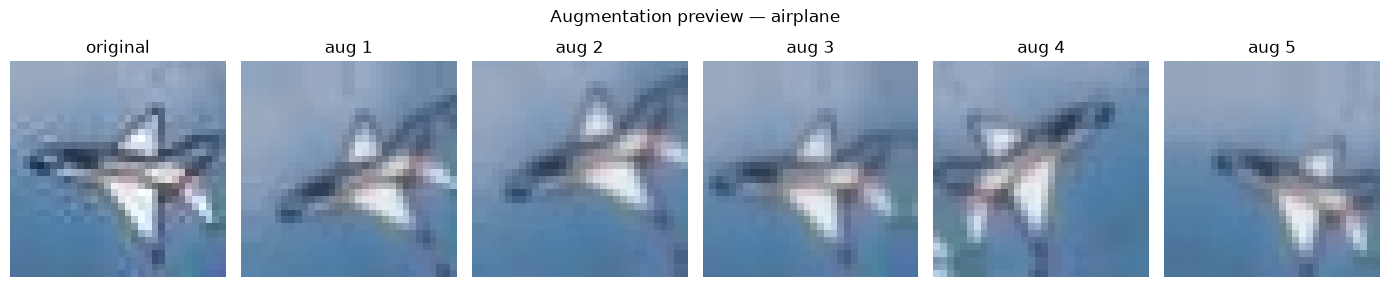

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1),
    ],
    name="augmentation",
)


sample = x_train[0:1]
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(sample[0])
axes[0].set_title("original")
axes[0].axis("off")
for i in range(1, 6):
    augmented = data_augmentation(sample, training=True)
    axes[i].imshow(augmented[0].numpy())
    axes[i].set_title(f"aug {i}")
    axes[i].axis("off")
plt.suptitle(f"Augmentation preview — {class_names[y_train[0]]}")
plt.tight_layout()
plt.show()

## 3. ConvNet model

Requirements:
- Input shape `(32, 32, 3)`
- Include your augmentation as the first stage of the graph (training only behaviour is fine)
- At least two `Conv2D` + pooling stages, then a dense classifier for 10 classes
- Name at least one early conv layer (you will need the name for visualisation)

Compile with a suitable loss for integer class labels (or one-hot — be consistent).


In [5]:
inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)

x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2d_1")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2d_2")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.3)(x)

x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv2d_3")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.4)(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="cifar10_convnet")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "cifar10_convnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 4. Train & evaluate

Fit with `validation_data`. Aim for **>65%** test accuracy (Moodle wants the percentage).
Plot train vs val accuracy if useful for your write-up.


Epoch 1/40
352/352 - 179s - 509ms/step - accuracy: 0.2526 - loss: 2.0335 - val_accuracy: 0.2444 - val_loss: 3.1404
Epoch 2/40
352/352 - 155s - 439ms/step - accuracy: 0.3434 - loss: 1.7795 - val_accuracy: 0.4350 - val_loss: 1.5396
Epoch 3/40
352/352 - 170s - 483ms/step - accuracy: 0.3927 - loss: 1.6724 - val_accuracy: 0.4834 - val_loss: 1.3891
Epoch 4/40
352/352 - 149s - 422ms/step - accuracy: 0.4222 - loss: 1.5869 - val_accuracy: 0.4984 - val_loss: 1.4659
Epoch 5/40
352/352 - 177s - 503ms/step - accuracy: 0.4487 - loss: 1.5267 - val_accuracy: 0.5286 - val_loss: 1.2821
Epoch 6/40
352/352 - 185s - 527ms/step - accuracy: 0.4642 - loss: 1.4780 - val_accuracy: 0.5318 - val_loss: 1.3125
Epoch 7/40
352/352 - 144s - 410ms/step - accuracy: 0.4836 - loss: 1.4354 - val_accuracy: 0.5424 - val_loss: 1.3091
Epoch 8/40
352/352 - 152s - 432ms/step - accuracy: 0.4938 - loss: 1.4056 - val_accuracy: 0.4864 - val_loss: 1.5293
Epoch 9/40
352/352 - 143s - 406ms/step - accuracy: 0.5072 - loss: 1.3749 - val_a

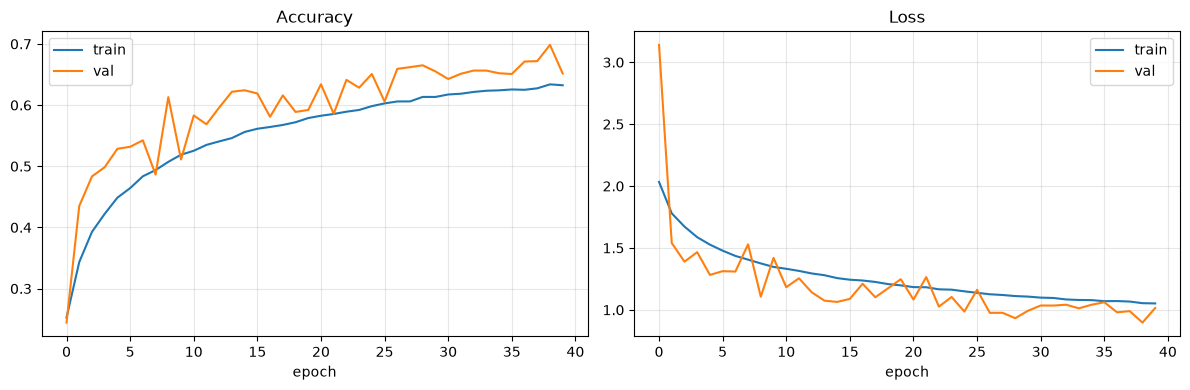

In [ ]:

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True,
)

history = model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=2,
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy % (Moodle a4_test_acc): {100 * test_acc:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Filter visualisation

Pick a named conv layer (`a4_filter_layer`). Minimum expectation: plot first-layer filter weights as small images.

Optional deeper approach: gradient ascent / activation maximisation for one filter index (Ch 10 style).


filter block shape (kh, kw, in_ch, out_ch): (3, 3, 3, 32)


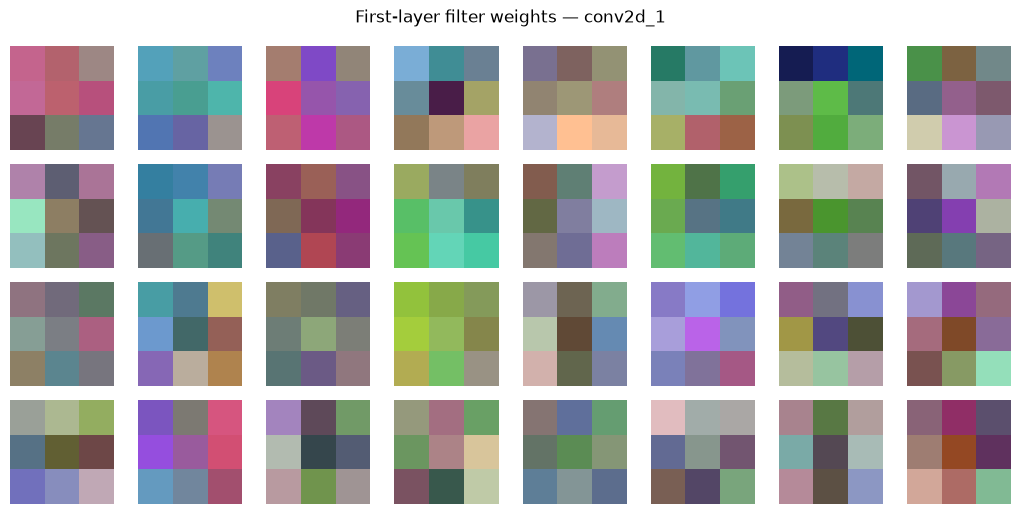

Visualisation layer (Moodle a4_filter_layer): conv2d_1


In [ ]:
VIS_LAYER = "conv2d_1" 

conv_layer = model.get_layer(VIS_LAYER)
filters, biases = conv_layer.get_weights()
print("filter block shape (kh, kw, in_ch, out_ch):", filters.shape)

f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

n_filters = filters_norm.shape[-1]
n_cols = 8
n_rows = int(np.ceil(n_filters / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.3, n_rows * 1.3))
for i, ax in enumerate(axes.flat):
    if i < n_filters:
        ax.imshow(filters_norm[:, :, :, i])
    ax.axis("off")
plt.suptitle(f"First-layer filter weights — {VIS_LAYER}")
plt.tight_layout()
plt.show()

print(f"Visualisation layer (Moodle a4_filter_layer): {VIS_LAYER}")

### Deeper approach: activation maximisation (gradient ascent)

Instead of only looking at raw weights, synthesise the input pattern that **maximises**
one filter's activation in a deeper layer (`conv2d_2`), following the Ch.10-style
gradient-ascent recipe: start from random noise, repeatedly nudge the pixels in the
direction that increases the mean activation of that filter.

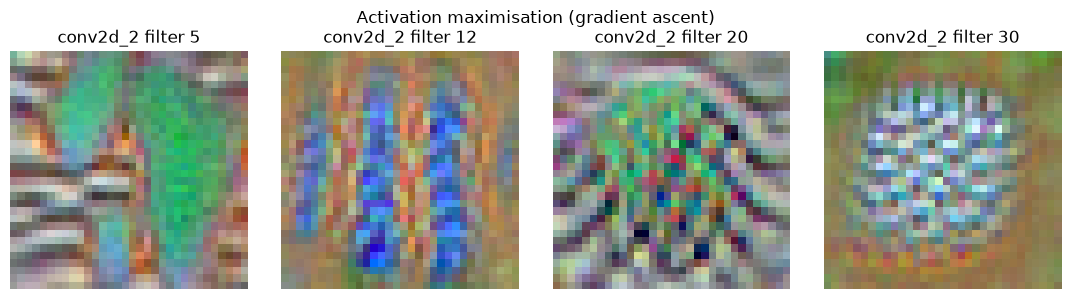

In [ ]:
AM_LAYER = "conv2d_2"
AM_FILTER = 5

feature_extractor = keras.Model(
    inputs=model.inputs, outputs=model.get_layer(AM_LAYER).output
)


def compute_loss(image, filter_index):
    activation = feature_extractor(image)
    filter_activation = activation[:, 2:-2, 2:-2, filter_index]
    return tf.reduce_mean(filter_activation)


@tf.function
def gradient_ascent_step(image, filter_index, learning_rate):
    with tf.GradientTape() as tape:
        tape.watch(image)
        loss = compute_loss(image, filter_index)
    grads = tape.gradient(loss, image)
    grads = tf.math.l2_normalize(grads)
    image += learning_rate * grads
    return image


def generate_pattern(filter_index, size=32, iterations=40, lr=10.0):
    image = tf.random.uniform((1, size, size, 3), minval=0.4, maxval=0.6)
    for _ in range(iterations):
        image = gradient_ascent_step(image, filter_index, lr)
    img = image[0].numpy()
    img -= img.mean()
    img /= img.std() + 1e-5
    img *= 0.15
    img += 0.5
    return np.clip(img, 0, 1)


fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, filt in zip(axes, [AM_FILTER, 12, 20, 30]):
    ax.imshow(generate_pattern(filt))
    ax.set_title(f"{AM_LAYER} filter {filt}")
    ax.axis("off")
plt.suptitle("Activation maximisation (gradient ascent)")
plt.tight_layout()
plt.show()

## 6. Interpretation (Moodle `a4_interpretation`)

Max ~200 words: what pattern does your chosen filter respond to?


I visualised conv2d_1 (32 filters, 3×3, applied directly on the RGB input) and additionally
synthesised activation-maximisation patterns for four filters of conv2d_2 via gradient ascent,
using the model that reached **69.24% test accuracy**.

The conv2d_1 grid is dominated by **colour-opponent patches** rather than sharp oriented edges:
each filter pairs one dominant colour against a contrasting one (magenta/grey, teal/brown,
blue/orange) split across the 3×3 patch. This is expected for a first layer on tiny 32×32
images — colour contrast is the cheapest, fastest signal to extract from raw pixels, and the
low resolution leaves little room for the clean oriented-edge detectors seen on larger inputs.

For the deeper conv2d_2 filter (index 5), the gradient-ascent image shows a rounded **green
blob** occupying the centre-right of the patch, bordered on both sides by diagonal light/dark
stripe texture. This filter has learned to respond to a compact green region with a
contrasting textured edge — plausibly useful for picking out foliage, grass, or green-bodied
objects (e.g. a frog) standing out against a differently-textured background. The neighbouring
filters (12, 20, 30) show wavy vertical ribbons, dense cross-hatched mesh, and a bright circular
blob respectively — evidence that one layer deeper, filters have moved from single colour
contrasts to small textures and rounded shape motifs.